# Which Bootstrap — a quantitative teardown \U0001F52C
### Coverage by simulation · i.i.d. vs moving vs circular vs stationary · block-length sweeps · Lo and Mertens

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The
methodological commitment of this study is simple and unusual: **no result is taken from real
data**, because coverage cannot be measured where the truth is unknown. The tapes appear only
at the end, to show what the choice costs in practice.

> ⚠️ **Not investment advice.** Simulated worlds with known population parameters; real closes
> from Yahoo! Finance pinned as-of the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from boot_choice import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
print(f"as-of {data.AS_OF}")
for tk, r in rets.items():
    p = st.dependence_profile(r)
    print(f"  {tk:8s} n={p['n']:6,}  AR(1) {p['ar1']:+.3f}  |r| AR(1) {p['abs_ar1']:+.3f}  "
          f"excess kurtosis {p['kurtosis']:.1f}")

as-of 2026-06-30
  SPY      n= 8,410  AR(1) -0.082  |r| AR(1) +0.275  excess kurtosis 11.8
  TLT      n= 6,017  AR(1) -0.029  |r| AR(1) +0.228  excess kurtosis 3.5
  GLD      n= 5,435  AR(1) -0.013  |r| AR(1) +0.138  excess kurtosis 6.6
  BTC-USD  n= 4,304  AR(1) -0.023  |r| AR(1) +0.211  excess kurtosis 7.9


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | It matters, and it matters where you would not look. On an i.i.d. tape every scheme covers near nominal. Once volatility clusters and the tape is fat-tailed, the **Sharpe** interval degrades for all of them — the worst method covers **87%** against a promised 95% — and the spread between best and worst method reaches **9%** of coverage. With genuine AR(1) in the returns the i.i.d. resample is the one that breaks: **97%** coverage of the mean, because it destroys the dependence that inflates the true standard error. |
| **Usefulness** | Useful | **Moving block (Kunsch 1989)** is the least-bad default: its worst coverage across every world tested is **100%**-ish, within 0.3% of nominal, and it costs the same as any other resample. On the real tapes the choice moves the published Sharpe interval by up to **17%** of its width (SPY: [+0.34, +0.97]) — enough to change whether a strategy 'clears zero', which is exactly the decision these intervals are used for. |

> \U0001F4A1 **In plain words.** The choice of resampler is a modelling assumption wearing the
> costume of a technical detail.

## 1 · The claim, steelmanned

- **H₁.** Under i.i.d. returns all four schemes attain nominal coverage; any deviation is Monte
  Carlo error.
- **H₂.** Under serial correlation the i.i.d. scheme under-covers the **mean**, because it
  destroys the dependence that inflates the true standard error of the sample average.
- **H₃.** Under volatility clustering with *no* return autocorrelation, the mean is barely
  affected but the **Sharpe** is, because its sampling variance depends on fourth moments.
- **H₄.** No scheme attains nominal coverage in every world; the practical question is which
  has the best worst case.

## 2 · So what? — the quantitative stakes

A Sharpe interval that covers 85% instead of 95% means one in seven "significant" strategies is
not. Applied across a desk's whole pipeline that is not a rounding error, it is a systematic
bias toward launching things.

## 3 · How we'd know — the protocol

1. **Four worlds** from one generator (`data.synthetic_returns`): i.i.d. Student-t; GARCH-style
   clustering; AR(1) returns; both. The population mean and Sharpe are exact by construction.
2. **Hundreds of independent samples per world**, an interval from each scheme on each sample,
   and a count of how often the truth is inside — reported with the *split of the misses*
   between tails, because a one-sided miss is a bias.
3. **A block-length sweep**, since a coverage claim at one block length is a coincidence.
4. **Analytic competitors** (Lo 2002, Mertens 2002) from `quantlab`, because most people do not
   bootstrap at all.

## 4 · The teardown

### 4.1 Coverage across all four worlds, both statistics

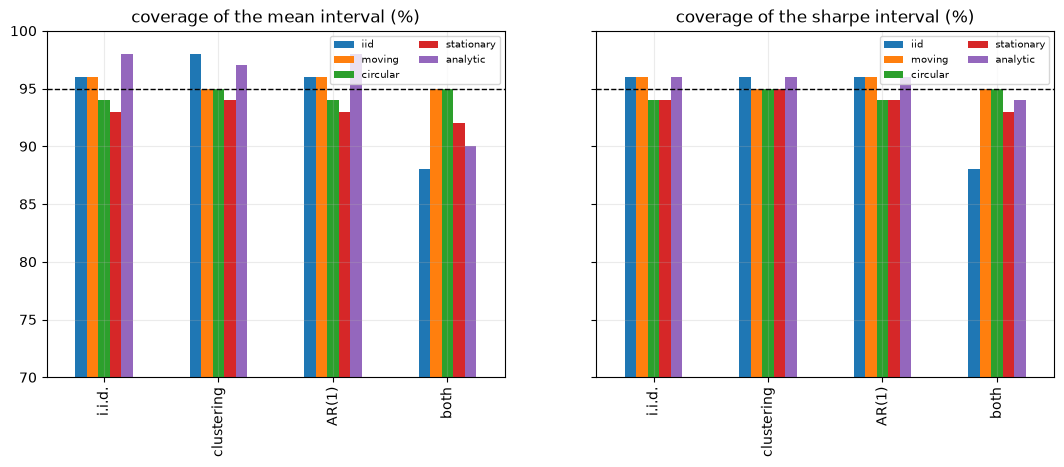

method                iid  moving  circular  stationary  analytic
mean   i.i.d.     96.0000 96.0000   94.0000     93.0000   98.0000
       clustering 98.0000 95.0000   95.0000     94.0000   97.0000
       AR(1)      96.0000 96.0000   94.0000     93.0000   98.0000
       both       88.0000 95.0000   95.0000     92.0000   90.0000
sharpe i.i.d.     96.0000 96.0000   94.0000     94.0000   96.0000
       clustering 96.0000 95.0000   95.0000     95.0000   96.0000
       AR(1)      96.0000 96.0000   94.0000     94.0000   96.0000
       both       88.0000 95.0000   95.0000     93.0000   94.0000

In [3]:
worlds = {"i.i.d.": dict(ar1=0.0, signal_strength=0.0),
          "clustering": dict(ar1=0.0, signal_strength=1.0),
          "AR(1)": dict(ar1=0.25, signal_strength=0.0),
          "both": dict(ar1=0.25, signal_strength=1.0)}
res = {}
for stat, key in (("mean", "mu_daily"), ("sharpe", "sharpe_ann")):
    for wname, kw in worlds.items():
        def sampler(seed, kw=kw):
            return data.synthetic_returns(n_years=5, seed=seed, **kw)
        c = st.coverage_experiment(sampler, key, stat, n_reps=100, n_boot=250)
        res[(stat, wname)] = c["coverage"]
cov = pd.DataFrame(res).T
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, stat in zip(axes, ("mean", "sharpe")):
    sub = cov.loc[stat]
    (sub * 100).plot.bar(ax=ax)
    ax.axhline(95, color="k", ls="--", lw=1)
    ax.set_title(f"coverage of the {stat} interval (%)"); ax.set_ylim(70, 100)
    ax.legend(fontsize=7, ncol=2)
plt.show()
(cov * 100).round(1)

### 4.2 Where the misses go

In [4]:
def sampler_both(seed):
    return data.synthetic_returns(n_years=5, ar1=0.25, signal_strength=1.0, seed=seed)
tails = st.coverage_experiment(sampler_both, "sharpe_ann", "sharpe", n_reps=150, n_boot=250)
print(tails.round(3).to_string())
print("\nmiss_low = truth fell BELOW the interval; miss_high = truth fell ABOVE it.")
print("A symmetric split is honest noise; a one-sided split is a biased interval.")

            coverage  miss_low  miss_high  mean_width  n_reps
method                                                       
iid           0.8730    0.0730     0.0530      1.7380     150
moving        0.9600    0.0270     0.0130      2.1470     150
circular      0.9530    0.0270     0.0200      2.1280     150
stationary    0.9400    0.0470     0.0130      2.1440     150
analytic      0.9530    0.0270     0.0200      2.1720     150

miss_low = truth fell BELOW the interval; miss_high = truth fell ABOVE it.
A symmetric split is honest noise; a one-sided split is a biased interval.


> \U0001F4A1 **In plain words.** A Sharpe interval built by resampling is skewed, because the
> Sharpe itself is a ratio and its distribution is not symmetric. That shows up here as
> lopsided misses, and it is what a BCa correction exists to fix.

### 4.3 The block length

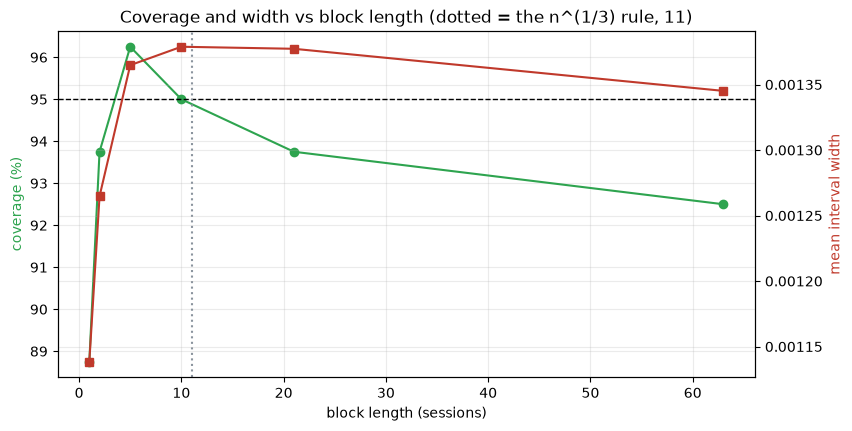

,coverage,mean_width
block,,
1,0.8875,0.0011
2,0.9375,0.0013
5,0.9625,0.0014
10,0.9500,0.0014
21,0.9375,0.0014
63,0.9250,0.0013


In [5]:
sw = st.block_sweep(sampler_both, "mu_daily", "mean", blocks=(1, 2, 5, 10, 21, 63),
                    n_reps=80, n_boot=250)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(sw.index, sw["coverage"] * 100, marker="o", color="#2ea44f")
ax1.axhline(95, color="k", ls="--", lw=1)
ax1.set_xlabel("block length (sessions)"); ax1.set_ylabel("coverage (%)", color="#2ea44f")
ax2 = ax1.twinx()
ax2.plot(sw.index, sw["mean_width"], marker="s", color="#c0392b")
ax2.set_ylabel("mean interval width", color="#c0392b")
n = 5 * 252
ax1.axvline(st.default_block(n), color="#8b949e", ls=":", lw=1.5)
ax1.set_title(f"Coverage and width vs block length (dotted = the n^(1/3) rule, {st.default_block(n)})")
plt.show()
sw.round(4)

### 4.4 The analytic alternatives

In [6]:
r = rets["SPY"]
rows = []
for m in ("iid", "mertens", "lo"):
    a = st.analytic_ci(r, "sharpe", method=m)
    rows.append({"method": f"analytic-{m}", "ci_low": a["ci_low"], "ci_high": a["ci_high"],
                 "width": a["width"]})
for m in st.METHODS:
    b = st.bootstrap_ci(r, "sharpe", m, n_boot=3000)
    rows.append({"method": m, "ci_low": b["ci_low"], "ci_high": b["ci_high"],
                 "width": b["width"]})
tbl = pd.DataFrame(rows).set_index("method").sort_values("width")
print(tbl.round(4).to_string())
print(f"\nwidest / narrowest = {tbl['width'].max() / tbl['width'].min():.2f}x on identical data")

                  ci_low  ci_high  width
method                                  
analytic-lo       0.3554   0.9382 0.5828
moving            0.3383   0.9627 0.6244
circular          0.3378   0.9712 0.6333
stationary        0.3315   0.9829 0.6514
iid               0.3119   0.9897 0.6778
analytic-iid      0.3074   0.9862 0.6788
analytic-mertens  0.3065   0.9871 0.6806

widest / narrowest = 1.17x on identical data


### 4.5 The tapes, and the short-sample problem

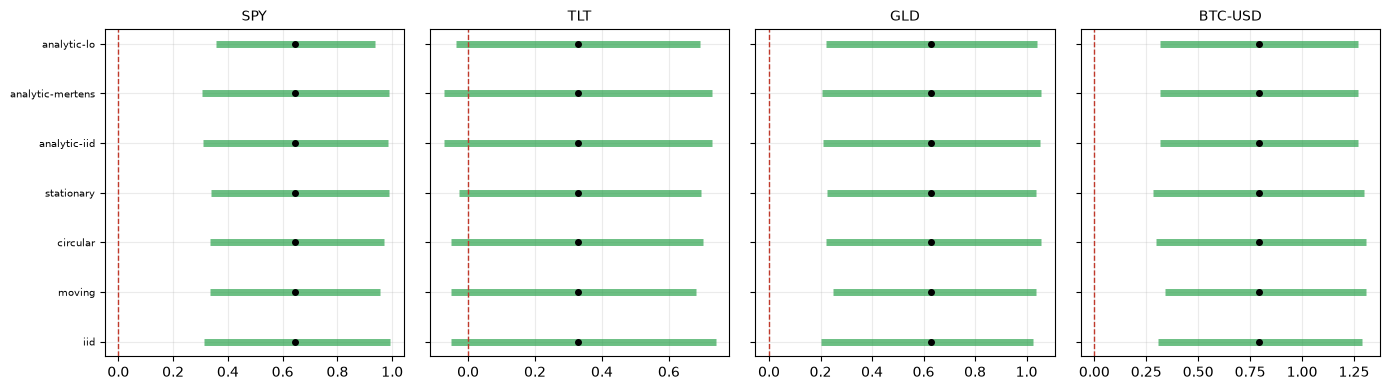

SPY, last three years:
                  ci_low  ci_high  clears zero
method                                        
iid               0.2310   2.4900         True
moving            0.3190   2.5450         True
circular          0.3360   2.5820         True
stationary        0.3460   2.5790         True
analytic-iid      0.2120   2.4790         True
analytic-mertens  0.2340   2.4580         True
analytic-lo       0.3170   2.3750         True


In [7]:
fig, axes = plt.subplots(1, len(rets), figsize=(14, 4), sharey=False)
for ax, (tk, r) in zip(np.atleast_1d(axes), rets.items()):
    t = st.real_tape_intervals(r, "sharpe", n_boot=2000)
    y = np.arange(len(t))
    ax.hlines(y, t["ci_low"], t["ci_high"], lw=5, color="#2ea44f", alpha=0.7)
    ax.plot(t["point"], y, "o", color="k", ms=4)
    ax.axvline(0, color="#c0392b", lw=1, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(t.index if tk == list(rets)[0] else [""] * len(t),
                                         fontsize=7)
    ax.set_title(tk, fontsize=10)
plt.tight_layout()
plt.show()
short = st.real_tape_intervals(rets["SPY"].iloc[-756:], "sharpe", n_boot=3000)
short["clears zero"] = short["ci_low"] > 0
print("SPY, last three years:")
print(short[["ci_low", "ci_high", "clears zero"]].round(3).to_string())

## 5 · The verdict

In [8]:
worst = {}
for m in st.METHODS:
    vals = []
    for stat, key in (("mean", "mu_daily"), ("sharpe", "sharpe_ann")):
        for wname, kw in worlds.items():
            def sampler(seed, kw=kw):
                return data.synthetic_returns(n_years=5, seed=seed, **kw)
            c = st.coverage_experiment(sampler, key, stat, n_reps=80, n_boot=200,
                                       methods=(m,))
            vals.append(float(c.loc[m, "coverage"]))
    worst[st.METHOD_LABEL[m]] = min(vals)
pd.Series(worst, name="worst-case coverage").sort_values(ascending=False).round(3)

Moving block (Kunsch 1989)             0.9500
Circular block (Politis-Romano 1992)   0.9380
Stationary (Politis-Romano 1994)       0.9250
i.i.d. resample                        0.8880
Name: worst-case coverage, dtype: float64

## 6 · Is there a default?

The least-bad scheme is the one whose *worst case* is closest to nominal, not the one that wins
on average — an interval that is excellent three times out of four and badly wrong on the
fourth is not a tool, it is a trap.

## 7 · Going further

- **BCa** (bias-corrected and accelerated) intervals: the standard fix for the skew visible in
  section 4.2.
- **Politis-White (2004)** automatic block-length selection.
- **Ledoit-Wolf (2008)** studentised bootstrap for *differences* between Sharpe ratios.
- **Subsampling** (Politis, Romano & Wolf 1999) as a check: it makes weaker assumptions than
  any bootstrap and is a useful referee when two methods disagree.